### Read training, dev and unlabeled test data

The following provides a starting code (Python 3) of how to read the labeled training and dev sentence pairs, and unlabeled test sentence pairs, into lists.

### Main Code Body

You may choose to experiment with different methods using your program. However, you need to embed the training and inference processes at here. We will use your prediction on the unlabeled test data to grade, while checking this part to understand how your method has produced the predictions.

In [1]:
import pandas as pd
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
import optuna

# Load the datasets
train_df = pd.read_csv('data/pnli_train.csv', sep=',', header=None, names=['precondition', 'statement', 'label'])
dev_df = pd.read_csv('data/pnli_dev.csv', sep=',', header=None, names=['precondition', 'statement', 'label'])
test_df = pd.read_csv('data/pnli_test_unlabeled.csv', sep=',', header=None, names=['precondition', 'statement'])

# Check the datasets
train_df.head()
dev_df.head()
test_df.head()

/mnt/c/Users/Yifei/Documents/NoodlePy/noodlepy/noodlepyvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,precondition,statement
0,The people want to have a romantic and pleasan...,People typically does desire to smell violets.
1,The contract is to buy products from you.,Getting contract typically cause to make money...
2,Train station is closed.,Line can typically be used to move train along...
3,There is no water for driving the boats.,People typically desires drive boats for fun.
4,The poet is busy.,Poet can typically be used for creating poetry.


In [14]:
# Load the tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

class PNLIDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.tokenizer = tokenizer
        self.data = dataframe
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        row = self.data.iloc[index]
        precondition = row['precondition']
        statement = row['statement']
        inputs = self.tokenizer(
            precondition, statement, 
            truncation=True, padding='max_length', max_length=self.max_len, return_tensors="pt"
        )
        input_ids = inputs['input_ids'].squeeze()
        attention_mask = inputs['attention_mask'].squeeze()
        label = torch.tensor(row['label'], dtype=torch.long) if 'label' in row else None
        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'label': label
        }
    

def get_optimizer(optimizer_name, model_parameters, lr):
    if optimizer_name == 'AdamW':
        return optim.AdamW(model_parameters, lr=lr)
    elif optimizer_name == 'SGD':
        return optim.SGD(model_parameters, lr=lr, momentum=0.9)
    elif optimizer_name == 'RMSprop':
        return optim.RMSprop(model_parameters, lr=lr)
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")
    
# Evaluate function
def evaluate(model, data_loader, device):
    model.eval()
    total_correct = 0
    total_examples = 0
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()
            _, preds = torch.max(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_examples += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = total_correct / total_examples
    return avg_loss, accuracy

def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_loguniform('lr', 9e-7, 9e-6)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    optimizer_name = trial.suggest_categorical('optimizer', ['AdamW', 'SGD'])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Create DataLoader for training and validation
    train_loader = DataLoader(PNLIDataset(train_df, tokenizer), batch_size=batch_size, shuffle=True)
    dev_loader = DataLoader(PNLIDataset(dev_df, tokenizer), batch_size=128, shuffle=False)

    # Set up the optimizer
    optimizer = get_optimizer(optimizer_name, model.parameters(), lr)
    criterion = nn.CrossEntropyLoss()

    # Train the model
    num_epochs = 6  # Use a smaller number of epochs for hyperparameter tuning
    best_val_loss = float('inf')
    early_stopping_patience = 3
    patience_counter = 0

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in tqdm(train_loader, desc=f"Training Epoch {epoch + 1}"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch + 1}, Training loss: {avg_train_loss:.4f}")

        # Validate the model
        val_loss, val_accuracy = evaluate(model, dev_loader, device)
        print(f"Epoch {epoch + 1}, Validation loss: {val_loss:.4f}, Validation accuracy: {val_accuracy:.4f}")

        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            # Save the best model
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            patience_counter += 1

        if patience_counter >= early_stopping_patience:
            print("Early stopping triggered")
            break

        if val_accuracy < 0.88:
            print("Accuracy is too low, terminating the trial")
            break

        if val_loss > 0.2:
            print("Loss is too high, terminating the trial")
            break

    # Load the best model
    model.load_state_dict(torch.load('best_model.pt'))
    return best_val_loss

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
[I 2024-05-22 13:45:20,239] A new study created in memory with name: no-name-dfa86bab-d0e5-4b1d-bb42-f8983ffa4803
/tmp/ipykernel_41723/3360192056.py:70: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 9e-7, 9e-6)
Training Epoch 1: 100%|██████████| 187/187 [00:15<00:00, 11.90it/s]


Epoch 1, Training loss: 0.5750


Evaluating: 100%|██████████| 9/9 [00:00<00:00,  9.45it/s]


Epoch 1, Validation loss: 0.3616, Validation accuracy: 0.8379
Accuracy is too low, terminating the trial


[I 2024-05-22 13:45:39,744] Trial 0 finished with value: 0.36164431108368766 and parameters: {'lr': 7.739971457269386e-06, 'batch_size': 32, 'optimizer': 'AdamW'}. Best is trial 0 with value: 0.36164431108368766.
Training Epoch 1: 100%|██████████| 187/187 [00:15<00:00, 11.97it/s]


...

Epoch 8, Training loss: 0.1012


Evaluating: 100%|██████████| 33/33 [00:00<00:00, 36.65it/s]


Epoch 8, Validation loss: 0.4244, Validation accuracy: 0.8720
Early stopping triggered


Evaluating: 100%|██████████| 33/33 [00:01<00:00, 31.51it/s]


Validation loss: 0.3343, Validation accuracy: 0.8749


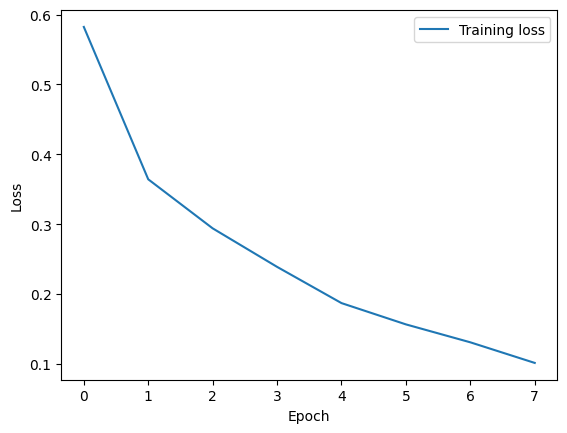

Predicting:   0%|          | 0/152 [00:00<?, ?it/s]


TypeError: default_collate: batch must contain tensors, numpy arrays, numbers, dicts or lists; found <class 'NoneType'>

In [15]:
# Perform hyperparameter optimization
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

# Print best hyperparameters
print('Best hyperparameters:', study.best_params)

# Train final model with best hyperparameters
best_params = study.best_params
train_loader = DataLoader(PNLIDataset(train_df, tokenizer), batch_size=best_params['batch_size'], shuffle=True)
dev_loader = DataLoader(PNLIDataset(dev_df, tokenizer), batch_size=best_params['batch_size'], shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)
model.to(device)

optimizer = get_optimizer(best_params['optimizer'], model.parameters(), best_params['lr'])
criterion = nn.CrossEntropyLoss()
train_loss_list = []

num_epochs = 20
best_val_loss = float('inf')
early_stopping_patience = 3
patience_counter = 0

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch + 1}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_loss_list.append(avg_train_loss)
    print(f"Epoch {epoch + 1}, Training loss: {avg_train_loss:.4f}")

    # Validate the model
    val_loss, val_accuracy = evaluate(model, dev_loader, device)
    print(f"Epoch {epoch + 1}, Validation loss: {val_loss:.4f}, Validation accuracy: {val_accuracy:.4f}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        # Save the best model
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        patience_counter += 1

    if patience_counter >= early_stopping_patience:
        print("Early stopping triggered")
        break

# Load the best model
model.load_state_dict(torch.load('best_model.pt'))

# Save the final model
model.save_pretrained('models/roberta_pnli')
tokenizer.save_pretrained('models/roberta_pnli')

# Evaluate on the dev set
dev_loss, dev_accuracy = evaluate(model, dev_loader, device)
print(f"Validation loss: {dev_loss:.4f}, Validation accuracy: {dev_accuracy:.4f}")

plt.plot(train_loss_list, label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Make predictions on the test set
test_loader = DataLoader(PNLIDataset(test_df, tokenizer), batch_size=best_params['batch_size'], shuffle=False)

def predict(model, data_loader, device):
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)
            predictions.extend(preds.cpu().numpy())

    return predictions

results = predict(model, test_loader, device)
assert (len(results) == 4850)
results = [int(x) for x in results]

with open('upload_predictions.txt', 'w', encoding='utf-8') as fp:
    for x in results:
        fp.write(str(x) + '\n')

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Set up the optimizer and loss function
optimizer = optim.AdamW(model.parameters(), lr=9e-6)
criterion = nn.CrossEntropyLoss()
train_loss_list = []

# Train the model
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Training Epoch {epoch + 1}"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    # track the loss in each epoch
    train_loss_list.append(avg_train_loss)
    print(f"Epoch {epoch + 1}, Training loss: {avg_train_loss:.4f}")

# Save the model
model.save_pretrained('models/roberta_pnli')
tokenizer.save_pretrained('models/roberta_pnli')


In [ ]:
# Evaluate the model
def evaluate(model, data_loader, device):
    model.eval()
    total_correct = 0
    total_examples = 0
    total_loss = 0
    val_loss_list = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits
            
            total_loss += loss.item()
            _, preds = torch.max(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_examples += labels.size(0)

    avg_loss = total_loss / len(data_loader)
    accuracy = total_correct / total_examples
    return avg_loss, accuracy

# Evaluate on the dev set
dev_loss, dev_accuracy = evaluate(model, dev_loader, device)
print(f"Validation loss: {dev_loss:.4f}, Validation accuracy: {dev_accuracy:.4f}")

plt.plot(train_loss_list, label='Training loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
# Make predictions on the test set

def predict(model, data_loader, device):
    model.eval()
    predictions = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc="Predicting"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            
            outputs = model(input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            _, preds = torch.max(logits, dim=1)
            predictions.extend(preds.cpu().numpy())
    
    return predictions

# Make predictions on the test set
results = predict(model, test_loader, device)

### Output Prediction Result File

You will need to submit a prediction result file. It should have 2028 lines, every line should be either 0 or 1, which is your model's prediction on the respective test set instance.

In [ ]:
# suppose you had your model's predictions on the 2028 test cases read from test_enc_unlabeled.tsv, and 
#those results are in the list called 'results'
assert (len(results) == 4850)

In [ ]:
# make sure the results are not float numbers, but intergers 0 and 1
results = [int(x) for x in results]

In [ ]:
# write your prediction results to 'upload_predictions.txt' and upload that later
with open('upload_predictions.txt', 'w', encoding = 'utf-8') as fp:
    for x in results:
        fp.write(str(x) + '\n')